In [1]:
import sys
sys.path.append('..')
from experiment_utils import read_config_file, get_site_splits
from utils import get_project_dir
from eval_utils import compare_aligned_data

import numpy as np
import os
import rasterio

import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt


import pandas as pd
import seaborn as sns

In [2]:
# to get the different test sets
config_fp = '../experiment_configs/train_baseline_local_models.yaml'
cfg_hp_search = read_config_file(config_fp)
cfg_data = cfg_hp_search['data']
split_seed = cfg_data['split_seed']


# 1. get the data for model type and number of layers

In [3]:
project_dir = '..'
data_dir = os.path.join(project_dir, 'data')
outputs_dir = '/n/tambe_lab/Everyone/model_output/subsetted_train_sites'
outputs_dir_rf = '../model_output/subsetted_training_sets'
resolution = 10
split_seed = 10
pred_padding = 40 # defined by how we cropped the satellite imagery to the Karingani sites
lidar_coarsened_dir = f'{project_dir}/data/int/lidar/lidar_by_site_32736_{resolution}m'
sites = sorted([x for x in os.listdir(lidar_coarsened_dir) if not x.startswith('.')])
#reference_maps = ['ETH', 'GLAD', 'META']
reference_maps = []
random_trial_seeds = np.arange(10)

models_rf = [f'rf_{x}' for x in ['12_channel']]
models_fcn = [f'local_only_models/128_filters/{x}' for x in ['3_channels', '4_channels', '12_channels', '15_channels']]
models_xception = [f'finetune_xceptionS2/pretrained/{x}' for x in ['3_layers_tuned']]
models_xception += [f'finetune_xceptionS2/randominit_nolatlon/{x}' for x in ['3_layers_tuned']]
models_unet = [f'unet/pretrained/{x}' for x in ['freeze_backbone_True']] + [f'unet/randominit/{x}' for x in ['12_channels',]]

models =  models_unet + models_fcn + models_xception

#pred padding is defined by how we cropped the satellite imagery to Karingani sites
pred_padding = 40

eval_metric = 'rmse'

lidar_coarsened_dir = f'{project_dir}/data/int/lidar/lidar_by_site_32736_{resolution}m'
sites = sorted([x for x in os.listdir(lidar_coarsened_dir) if not x.startswith('.')])


In [4]:
# aggregate predictions and calculate performance metrics
results_aggregated = {x: {} for x in reference_maps + models + models_rf}
results_by_split = {x: {} for x in reference_maps + models + models_rf}

In [5]:
results_print_models_by_seed = pd.DataFrame()
results_print_models_by_split_and_seed = pd.DataFrame()


for trial in random_trial_seeds:
    for model in models:
        labels = []
        preds = []
        model_output_dir = f'{outputs_dir}/{model}'

        for split_number in range(4):
            labels_by_split = []
            preds_by_split = []
            test_sites = get_site_splits(split_seed, data_dir = data_dir)[split_number]['test_sites']

            for site in test_sites:

                with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
                    site_labels = file.read().ravel()
                    labels = np.append(labels, site_labels)
                    labels_by_split = np.append(labels_by_split, site_labels)

                with rasterio.open(f'{model_output_dir}/12_train_sites/seed_{trial}/preds_{site}.tif') as file: # opens prediction tiff
                    site_preds = file.read()[:, pred_padding:-pred_padding, pred_padding:-pred_padding].ravel()
                    preds = np.append(preds, site_preds)
                    preds_by_split = np.append(preds_by_split, site_preds)

   #             results_by_site[model][site] = compare_aligned_data(site_labels, site_preds)
            results_by_split[model][split_number] = compare_aligned_data(labels_by_split, preds_by_split)
            
            row_this_split = pd.DataFrame({x: results_by_split[model][split_number][x] for x in ['r2', 'rmse', 'mae']}, index = [0])
            row_this_split.loc[:,'trial_seed'] = trial
            row_this_split.loc[:,'model'] = model
            row_this_split.loc[:,'split'] = split_number
            results_print_models_by_split_and_seed = pd.concat((results_print_models_by_split_and_seed, pd.DataFrame(row_this_split)))
            
        results_aggregated[model] = compare_aligned_data(labels, preds)
        
        row = pd.DataFrame({x: results_aggregated[model][x] for x in ['r2', 'rmse', 'mae']}, index = [0])
        row.loc[:,'trial_seed'] = trial
        row.loc[:,'model'] = model
        results_print_models_by_seed = pd.concat((results_print_models_by_seed, pd.DataFrame(row)))

In [6]:
for trial in random_trial_seeds:
    for model in models_rf:
        labels = []
        preds = []
        model_output_dir = f'{outputs_dir_rf}'
        
        for split_number in range(4):
            labels_by_split = []
            preds_by_split = []
            test_sites = get_site_splits(split_seed, data_dir = data_dir)[split_number]['test_sites']

            for site in test_sites:

                with rasterio.open(f'{lidar_coarsened_dir}/{site}/{site}_CHM_{resolution}m.tif') as file: # opens label tiff
                    site_labels = file.read().ravel()
                    labels = np.append(labels, site_labels)
                    labels_by_split = np.append(labels_by_split, site_labels)

                with rasterio.open(f'{model_output_dir}/12_train_sites/seed_{trial}/{model}/preds_{site}.tif') as file: # opens prediction tiff
                    site_preds = file.read()[:, pred_padding:-pred_padding, pred_padding:-pred_padding].ravel()
                    preds = np.append(preds, site_preds)
                    preds_by_split = np.append(preds_by_split, site_preds)

   #             results_by_site[model][site] = compare_aligned_data(site_labels, site_preds)
            results_by_split[model][split_number] = compare_aligned_data(labels_by_split, preds_by_split)
            
            row_this_split = pd.DataFrame({x: results_by_split[model][split_number][x] for x in ['r2', 'rmse', 'mae']}, index = [0])
            row_this_split.loc[:,'trial_seed'] = trial
            row_this_split.loc[:,'model'] = model
            row_this_split.loc[:,'split'] = split_number
            results_print_models_by_split_and_seed = pd.concat((results_print_models_by_split_and_seed, pd.DataFrame(row_this_split)))
            
        results_aggregated[model] = compare_aligned_data(labels, preds)
        
        row = pd.DataFrame({x: results_aggregated[model][x] for x in ['r2', 'rmse', 'mae']}, index = [0])
        row.loc[:,'trial_seed'] = trial
        row.loc[:,'model'] = model
        results_print_models_by_seed = pd.concat((results_print_models_by_seed, pd.DataFrame(row)))

In [7]:
# coalesce into pandas dataframes for plotting
results_keys = ['r2','mae','mse','rmse']

label_names_dict = {'ETH':'ETH', 
                    'GLAD':'GLAD', 
                    'local_only_models/128_filters/3_channels': 'FCN 3 channels (ours)',
                   'local_only_models/128_filters/4_channels': 'FCN 4 channels (ours)',
                   'local_only_models/128_filters/12_channels': 'FCN 12 channels (ours)',
                   'local_only_models/128_filters/15_channels': 'FCN 15 channels (ours)',
                   'local_only_models/rf/rf_3_channel': 'RF 3 channels (ours)',
                   'rf_4_channel': 'RF 4 channels (ours)',
                    'rf_12_channel': 'RF 12 channels (ours)',
                    'local_only_models/rf/rf_12_channel': 'RF 12 channels (ours)',
                    'local_only_models/rf/rf_15_channel': 'RF 15 channels (ours)',
                    'finetune_xceptionS2/pretrained/1_layers_tuned': 'XceptionS2 pretrained 1 layer tuned',
                    'finetune_xceptionS2/pretrained/2_layers_tuned': 'XceptionS2 pretrained 2 layers tuned',
                    'finetune_xceptionS2/pretrained/3_layers_tuned': 'XceptionS2 pretrained 3 layers tuned',
                    'finetune_xceptionS2/randominit_latlon/1_layers_tuned': 'XceptionS2 randominit 1 layer tuned',
                    'finetune_xceptionS2/randominit_latlon/2_layers_tuned': 'XceptionS2 randominit 2 layers tuned',
                    'finetune_xceptionS2/randominit_latlon/3_layers_tuned': 'XceptionS2 randominit 3 layers tuned',
                    'finetune_xceptionS2/randominit_nolatlon/1_layers_tuned': 'XceptionS2 (12 channel) randominit 1 layer tuned',
                    'finetune_xceptionS2/randominit_nolatlon/2_layers_tuned': 'XceptionS2 (12 channel) randominit 2 layers tuned',
                    'finetune_xceptionS2/randominit_nolatlon/3_layers_tuned': 'XceptionS2 (12 channel) randominit 3 layers tuned',
                    'unet/pretrained/freeze_backbone_False': 'U-Net pretrained everything tuned',
                    'unet/pretrained/freeze_backbone_True': 'U-Net pretrained decoder tuned',
                    'unet/randominit/12_channels': 'U-Net randominit everything tuned',
                   }

num_layers_dict = {'ETH': 'nan', 
                    'GLAD':'nan', 
                    'local_only_models/128_filters/3_channels': 3,
                   'local_only_models/128_filters/4_channels': 4,
                   'local_only_models/128_filters/12_channels': 12,
                   'local_only_models/128_filters/15_channels': 15,
                   'local_only_models/rf/rf_3_channel': 3,
                   'rf_4_channel': 4,
                   'rf_12_channel': 12,
                    'local_only_models/rf/rf_12_channel': 12,
                    'local_only_models/rf/rf_15_channel': 15,
                   'finetune_xceptionS2/pretrained/1_layers_tuned': 15,
                    'finetune_xceptionS2/pretrained/2_layers_tuned': 15,
                   'finetune_xceptionS2/pretrained/3_layers_tuned': 15,
                   'finetune_xceptionS2/randominit_latlon/1_layers_tuned': 15,
                    'finetune_xceptionS2/randominit_latlon/2_layers_tuned': 15,
                    'finetune_xceptionS2/randominit_latlon/3_layers_tuned': 15,
                   'finetune_xceptionS2/randominit_nolatlon/1_layers_tuned': 12,
                    'finetune_xceptionS2/randominit_nolatlon/2_layers_tuned': 12,
                    'finetune_xceptionS2/randominit_nolatlon/3_layers_tuned': 12,
                    'unet/pretrained/freeze_backbone_False': 12,
                    'unet/pretrained/freeze_backbone_True': 12,
                    'unet/randominit/12_channels': 12,
                   }

for df in [results_print_models_by_seed, results_print_models_by_split_and_seed]:
    df['model_name'] = df['model'].apply(lambda x: label_names_dict[x])
    df['num_image_layers_used'] = df['model'].apply(lambda x: num_layers_dict[x])


# 2. get the data for different number of training sites


In [8]:
model_type = 'fcn'

results_with_subsetted_sites = pd.read_csv(f'../experiment_results/results_by_num_training_sites_{model_type}.csv')
results_with_subsetted_sites = results_with_subsetted_sites.rename(columns={ 'channel':'num_image_layers_used'})
results_with_subsetted_sites = results_with_subsetted_sites.loc[:,results_keys + ['seed','split', 'num_image_layers_used', 'num_train_sites']]
# #results_with_subsetted_sites.loc[:,'model_name'] = 'FCN 4 channels (ours)'

groups = ['split','num_train_sites']
grouped = results_with_subsetted_sites.groupby(groups)

results_by_num_sites = pd.DataFrame()
rows = []
for name, group in grouped:
    row_df = pd.DataFrame(group.mean()).T
    row_df.loc[:,'model_name'] = f'{model_type} ({name[1]} train sites)'
    row_df.loc[:,groups[0]] = name[0]
    row_df.loc[:,groups[1]] = name[1]
    
    results_by_num_sites= pd.concat((results_by_num_sites,row_df))
    
results_by_num_sites.sort_values(by='num_train_sites', inplace=True)

In [9]:
def plot_panel(results_by_split_df, ax, x_key='model_name', y_key='rmse', color='forestgreen', color_label='average across_test_splits'):

    means = results_by_split_df.groupby(x_key)[[y_key]].mean()
    sns.scatterplot(data=results_by_split_df.groupby(x_key)[[y_key]].mean(), x=x_key, y=y_key, 
                    s=120,
                    color=color, 
                    label=color_label,
                    ax=ax)
    
    x_values = list(results_by_split_df.groupby(x_key).groups.keys())
    means = results_by_split_df.groupby(x_key)[[y_key]].mean().values
    stderrs = results_by_split_df.groupby(x_key)[[y_key]].std().values / np.sqrt(len(means))

    ax.errorbar(x=x_values, 
                    y= means.ravel(),
                    yerr= stderrs.ravel(), 
                    color=color, 
                linewidth=0,
                elinewidth=2,
              capsize=10)
    
    sns.scatterplot(data=results_by_split_df.groupby([x_key, 'split'])[[y_key]].mean(), x=x_key,y=y_key, 
                    s=80,
               #     style='test_split',
                    color='lightgrey', 
                    label='each of 4 test splits',
                    ax=ax,
                   zorder=-1)
    
   
    
    
    
    return ax

/tmp/ipykernel_1369865/1441652218.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_by_model_type_local.loc[:,'plot_order'] =  results_by_model_type_local['model_name'].apply(lambda x: models_to_plot_order_local[x])
/tmp/ipykernel_1369865/1441652218.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_by_model_type_pretrained.loc[:,'plot_order'] =  results_by_model_type_pretrained['model_name'].apply(lambda x: models_to_plot_order_pretrained[x])
/tmp/ipykernel_1369865/1441652218.py:51: Se

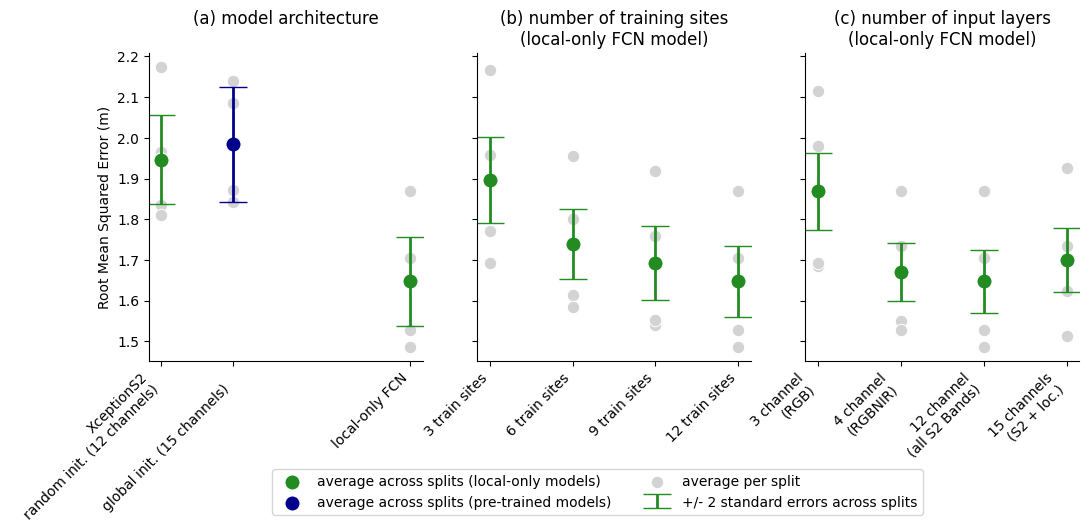

In [10]:
y_key = 'rmse'

results_by_model_type_local = results_print_models_by_seed
results_by_split_df = results_print_models_by_split_and_seed #[[y_key, 'split', 'model']].groupby(['split', 'model']).mean()

metric_labels = {'mae': "Mean Absolute Error (m)", 'rmse': "Root Mean Squared Error (m)"}

fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)

models_to_plot_order_local = {
                  'XceptionS2 (12 channel) randominit 3 layers tuned': 1,
                  'FCN 12 channels (ours)': 2.4
                 }

models_to_plot_order_pretrained = {
                    'XceptionS2 pretrained 3 layers tuned': 1.4,
                 }

rename_models_for_xlabels = {
    'XceptionS2 (12 channel) randominit 3 layers tuned': 'XceptionS2\nrandom init. (12 channels)',
    'XceptionS2 pretrained 3 layers tuned': '\nglobal init. (15 channels)',
    'FCN 12 channels (ours)':'local-only FCN',
    'U-Net randominit everything tuned':'U-Net\nrandom init.',
    'U-Net pretrained decoder tuned':'\nglobal init.',
    
}


results_by_model_type_local = results_by_split_df.loc[results_by_split_df['model_name'].apply(lambda x: x in models_to_plot_order_local.keys())]
results_by_model_type_local.loc[:,'plot_order'] =  results_by_model_type_local['model_name'].apply(lambda x: models_to_plot_order_local[x]) 
results_by_model_type_pretrained = results_by_split_df.loc[results_by_split_df['model_name'].apply(lambda x: x in models_to_plot_order_pretrained.keys())]
results_by_model_type_pretrained.loc[:,'plot_order'] =  results_by_model_type_pretrained['model_name'].apply(lambda x: models_to_plot_order_pretrained[x]) 


plot_panel(results_by_model_type_local, ax[0], x_key = 'plot_order', y_key='rmse', color_label='average across splits (local-only models)');
plot_panel(results_by_model_type_pretrained, ax[0], x_key = 'plot_order', y_key='rmse', color='darkblue', color_label=' average across splits (pre-trained models)');

model_names = list(models_to_plot_order_local.keys()) + list(models_to_plot_order_pretrained.keys())
model_orders = list(models_to_plot_order_local.values()) + list(models_to_plot_order_pretrained.values())
xtick_marks = np.sort(list(models_to_plot_order_local.values()) + list(models_to_plot_order_pretrained.values()))
xtick_labels = [rename_models_for_xlabels[model_names[x]] for x in np.argsort(model_orders)]


methods_by_sentinel_layers = ['FCN 3 channels (ours)', 'FCN 4 channels (ours)', 'FCN 12 channels (ours)', 'FCN 15 channels (ours)']
models_to_plot_order_layers = {'FCN 3 channels (ours)':0, 'FCN 4 channels (ours)':1, 'FCN 12 channels (ours)':2, 'FCN 15 channels (ours)':3}
results_by_sentinel_layers = results_by_split_df[results_by_split_df['model_name'].apply(lambda x: x in methods_by_sentinel_layers)]
results_by_sentinel_layers.loc[:,'plot_order'] =  results_by_sentinel_layers['model_name'].apply(lambda x: models_to_plot_order_layers[x]) 

plot_panel(results_by_sentinel_layers, ax[2], x_key='plot_order', y_key='rmse');

results_by_num_sites.loc[:,'plot_order'] =  results_by_num_sites.loc[:,'num_train_sites'] / 3. - 1
plot_panel(results_by_num_sites, ax[1], x_key = 'plot_order', y_key='rmse');

ax[0].set_xticks(xtick_marks, xtick_labels)
ax[2].set_xticks(np.arange(len(methods_by_sentinel_layers)))
ax[2].set_xticklabels(['3 channel\n(RGB)', '4 channel\n(RGBNIR)', '12 channel\n(all S2 Bands)', '15 channels\n(S2 + loc.)'])
ax[1].set_xticks(np.arange(4), [f'{x} train sites' for x in [3,6,9,12]])


for i in range(len(ax)):
    ax[i].set_xlabel(None)

for i,ax_this in enumerate(ax):
    ax_this.set_xticklabels(ax_this.get_xticklabels(), 
                          rotation=45, horizontalalignment='right')
    
    if i == 0: l = ax_this.legend(['average across splits (local-only models)','_','average across splits (pre-trained models) ','average per split','+/- 2 standard errors across splits'], 
                                  ncols=2,
                                 loc= (0.45,-.5))
    else:
        0
        ax_this.get_legend().remove()
        
   # ax_this.grid(axis='y')
    
ax[0].set_ylabel(metric_labels[y_key])
ax[0].set_title('(a) model architecture\n')
ax[2].set_title('(c) number of input layers\n(local-only FCN model)')
ax[1].set_title('(b) number of training sites\n(local-only FCN model)')

# for ax_this in ax: 
    # ax_this.set_ylim(1.25,2.85)
   # ax_this.axhline(1.75)
sns.despine()



plt.savefig('../figures/model_data_choices_with_rf_no_unet.png', bbox_inches='tight')

In [11]:
results_by_sentinel_layers.groupby('model_name')[['rmse']].mean()

,rmse
model_name,
FCN 12 channels (ours),1.647147
FCN 15 channels (ours),1.700046
FCN 3 channels (ours),1.868232
FCN 4 channels (ours),1.670567


In [12]:
(1.868232 - 1.670567)/ 1.868232

0.10580324071100376

In [13]:
(1.868232 - 1.647147)

0.22108499999999998

In [14]:
results_by_num_sites.groupby('num_train_sites')['rmse'].mean()

num_train_sites
3.0     1.897314
6.0     1.738484
9.0     1.692704
12.0    1.647147
Name: rmse, dtype: float64

In [15]:
1.897314- 1.647147

0.25016700000000003